In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [49]:
file_path = 'zomato_raw_data.csv'
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [50]:
funnel_stage = ['App Open', 'Search', 'Restaurant Viewed', 'Add to Cart',
       'Order Placed', 'Checkout', 'Payment']

In [51]:
def cleaning(file_path):
    df = pd.read_csv(file_path)

    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df = df.drop_duplicates()
    df = df.dropna(subset=['user_id', 'event', 'channel'])

    df['month'] = df['timestamp'].dt.to_period('M')
    df['week'] = df['timestamp'].dt.to_period('W')
    df['date'] = df['timestamp'].dt.date

    return df

In [52]:
def summary(df):
    # 1. % of people that opened the app and added something to the cart 
    summary_df = df.groupby('session_id').agg(
        {
            'user_id':'first',
            'timestamp':['min','max'],
            'event' : lambda x: list(x),
            'device':'first',
            'city':'first',
            'channel':'first',
            'cuisine_category':'first',
            'revenue':'max'
        }
    ).reset_index()
    summary_df.columns = ['session_id','user_id','session_start','session_end','event_sequence','device','city','channel','cuisine_category','revenue']
    
    # summary_df['session_start'] = pd.to_datetime(summary_df['session_start'])
    # summary_df['session_end'] = pd.to_datetime(summary_df['session_end'])

    
    summary_df['session_duration'] = (summary_df['session_end'] - summary_df['session_start']).dt.total_seconds()/60
    
    return summary_df

In [53]:
def max_funneling_stage(events):
    global funnel_stage
    stage_values = {stage:i for i,stage in enumerate(funnel_stage)}
    max_stage_index = -1
    for event in events:
        if event in stage_values and max_stage_index<stage_values[event]:
            max_stage_index = stage_values[event]

    return funnel_stage[max_stage_index] if max_stage_index !=-1 else 'App Open'

In [54]:
cleaned_df = cleaning(file_path)

In [55]:
summ_df = summary(cleaned_df)


In [56]:
summ_df['max_funnel_stage'] = summ_df['event_sequence'].apply(max_funneling_stage)

In [57]:
def funnel_analysis(summary_df):
    global funnel_stage
    funnel_metrics = []
    count = None
    for i,stage in enumerate(funnel_stage):
        if i ==0:
            count = len(summary_df)
        else:
            count = len(summary_df[summary_df['max_funnel_stage'].isin(funnel_stage[i:])])
        funnel_metrics.append(
            {
                'stage':stage,
                'sessions':count,
        
            }
        )
    funnel_metrics = pd.DataFrame(funnel_metrics)
    return funnel_metrics
    

In [58]:
funnel_df = funnel_analysis(summ_df)
funnel_df

,stage,sessions
0,App Open,5570
1,Search,4217
2,Restaurant Viewed,3498
3,Add to Cart,2747
4,Order Placed,1985
5,Checkout,1415
6,Payment,1203


In [94]:
funnel_df['conversion_rate'] = (funnel_df['sessions']/funnel_df['sessions'].shift(1))*100
funnel_df.loc[funnel_df.index[0], 'conversion_rate'] = 100

In [60]:
funnel_df['conversion_rate_top']=funnel_df['sessions'].apply(lambda x:x/funnel_df['sessions'].iloc[0]).mul(100).round(2)

In [61]:
funnel_df['dropoff_rate'] = 100 - funnel_df['conversion_rate']
funnel_df.loc[funnel_df.index[0], 'dropoff_rate'] = 0

In [95]:
def channel_analysis(summary_df):
    global funnel_stage
    channel_funnel = []
    count = None
    for channel in summary_df['channel'].unique():
        channel_summary = summary_df[summary_df['channel']==channel]
        total_sessions = channel_summary.shape[0]
        count = None
        if total_sessions > 0:
            channel_metrics = {'Channel':channel,'total_sessions':total_sessions}
            for i,stage in enumerate(funnel_stage):
                if i ==0:
                    count = total_sessions
                else:
                    count = len(channel_summary[channel_summary['max_funnel_stage'].isin(funnel_stage[i:])])
                channel_metrics[f'{stage}_session'] = count
                channel_metrics[f'{stage}_rate'] = (count/total_sessions)*100
                
        
        purchase_sessions = channel_summary[channel_summary['max_funnel_stage'] == 'Payment']
        channel_metrics['total_revenue'] = purchase_sessions['revenue'].sum()
        channel_metrics['AOV'] = purchase_sessions['revenue'].mean()  if len(purchase_sessions) > 0 else 0
        channel_metrics['conversion_rate'] = (len(purchase_sessions)/total_sessions) * 100

        channel_funnel.append(channel_metrics)

    channel_funnel = pd.DataFrame(channel_funnel)
    return channel_funnel

In [96]:
channel_df = channel_analysis(summ_df)
channel_df['session_per_channel'] = channel_df['total_sessions'].apply(lambda x:x/np.sum(channel_df['total_sessions'])) * 100 # this gives the % of session each channel brings

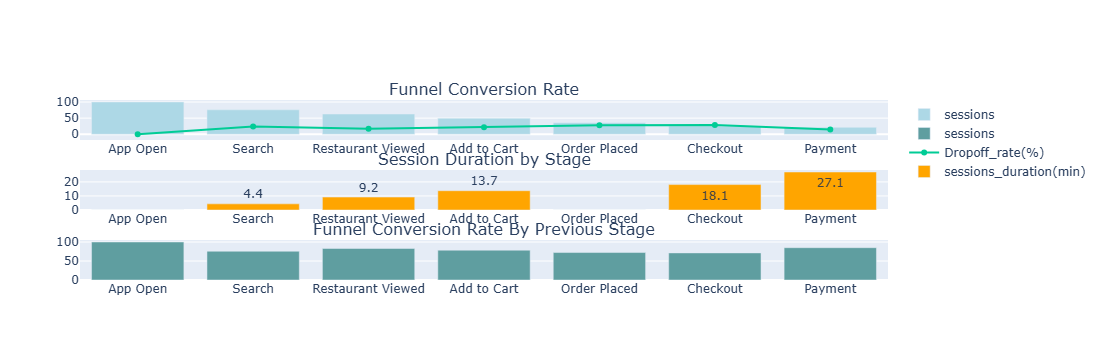

In [97]:
fig = make_subplots(
    rows=3,cols=1,
    subplot_titles=('Funnel Conversion Rate',
                     'Session Duration by Stage',
                    'Funnel Conversion Rate By Previous Stage'
                    )
)
fig.add_trace(
    go.Bar(x=funnel_df['stage'],y=funnel_df['conversion_rate_top'],name='sessions',marker_color='lightblue')
    ,row=1,col=1,secondary_y=False
)
fig.add_trace(
    go.Bar(x=funnel_df['stage'],y=funnel_df['conversion_rate'],name='sessions',marker_color='cadetblue')
    ,row=3,col=1,secondary_y=False
)
fig.add_trace(
    go.Scatter(x=funnel_df['stage'],y=funnel_df['dropoff_rate'],name='Dropoff_rate(%)',text=funnel_df['dropoff_rate'],textposition='top center')
)

durration_df = summ_df.groupby('max_funnel_stage')['session_duration'].mean().reset_index()
durration_df = durration_df.iloc[[1,6,5,0,3,2,4]]
fig.add_trace(
    go.Bar(x=durration_df['max_funnel_stage'],y=durration_df['session_duration'],text=durration_df['session_duration'].round(1),name='sessions_duration(min)',marker_color='orange')
    ,row=2,col=1,secondary_y=False
)



### Funnel Insights
<div class="alert alert-info">
<b>Observation:</b> TheThere is a spike in drop off rate from Restaurant Viewed to Add to Cart,This is the second largest droprate in the funnel
</div>


**Hypothesis:**
            
Total users Who Add to Cart = `Total users who View the restaurant` * `% of the people who add to cart`

Total users who View the restaurant -> Segmented based on `location` and `Acquisition Channel`

pct of the People who add to cart - > Segmented based on `Device` and `New Commers vs Repeat Order Customers`

- There might be increase in price due to which the customers from low income area(tier 2/tier 3 cities) are Dropping off. 
- Changes in UI for a particular Device (Andriod,Web,IOS) can cause people to drop off.
- Channel Might be not providing the right Ads to the customer which can cause disatisfaction and resulting in drop off.

### Stage wise drop off Rate for each Channel


In [99]:
dropoff_channel = channel_df[channel_df.columns[channel_df.columns.str.contains('session')]].copy()

In [100]:
dropoff_channel.rename(index = channel_df['Channel'],inplace=True)

In [67]:
dropoff_channel = dropoff_channel.T
dropoff_channel

,Organic,Social Media,Google Ads,Email
total_sessions,1483.000000,1363.000000,1599.000000,1125.000000
App Open_session,1483.000000,1363.000000,1599.000000,1125.000000
Search_session,1226.000000,999.000000,1090.000000,902.000000
Restaurant Viewed_session,1083.000000,803.000000,843.000000,769.000000
Add to Cart_session,899.000000,611.000000,615.000000,622.000000
Order Placed_session,710.000000,430.000000,379.000000,466.000000
Checkout_session,517.000000,306.000000,272.000000,320.000000
Payment_session,458.000000,257.000000,215.000000,273.000000
session_per_channel,26.624776,24.470377,28.707361,20.197487


In [68]:
for column in dropoff_channel.columns:
    dropoff_channel[f'{column}_dropoff'] = 1 - dropoff_channel[column]/dropoff_channel[column].shift(1)
    dropoff_channel[f'{column}_dropoff'] = (dropoff_channel[f'{column}_dropoff']*100).round(2)


In [69]:
# We have to see the Successful Conversion Rate from each Channel
# For each column We will Divide the Payment_session by total Session For that Channel

for column in ['Organic',	'Social Media'	,'Google Ads',	'Email']:
    dropoff_channel[f'{column}_top_conversion_rate_']=dropoff_channel[column].apply(lambda x: (x/dropoff_channel.iloc[0][column])).mul(100).round(2)

In [70]:
dropoff_channel.iloc[0] = 0.00

In [71]:
dropoff_channel

,Organic,Social Media,Google Ads,Email,Organic_dropoff,Social Media_dropoff,Google Ads_dropoff,Email_dropoff,Organic_top_conversion_rate_,Social Media_top_conversion_rate_,Google Ads_top_conversion_rate_,Email_top_conversion_rate_
total_sessions,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
App Open_session,1483.000000,1363.000000,1599.000000,1125.000000,0.00,0.00,0.00,0.00,100.00,100.00,100.00,100.00
Search_session,1226.000000,999.000000,1090.000000,902.000000,17.33,26.71,31.83,19.82,82.67,73.29,68.17,80.18
Restaurant Viewed_session,1083.000000,803.000000,843.000000,769.000000,11.66,19.62,22.66,14.75,73.03,58.91,52.72,68.36
Add to Cart_session,899.000000,611.000000,615.000000,622.000000,16.99,23.91,27.05,19.12,60.62,44.83,38.46,55.29
Order Placed_session,710.000000,430.000000,379.000000,466.000000,21.02,29.62,38.37,25.08,47.88,31.55,23.70,41.42
Checkout_session,517.000000,306.000000,272.000000,320.000000,27.18,28.84,28.23,31.33,34.86,22.45,17.01,28.44
Payment_session,458.000000,257.000000,215.000000,273.000000,11.41,16.01,20.96,14.69,30.88,18.86,13.45,24.27
session_per_channel,26.624776,24.470377,28.707361,20.197487,94.19,90.48,86.65,92.60,1.80,1.80,1.80,1.80


<Axes: >

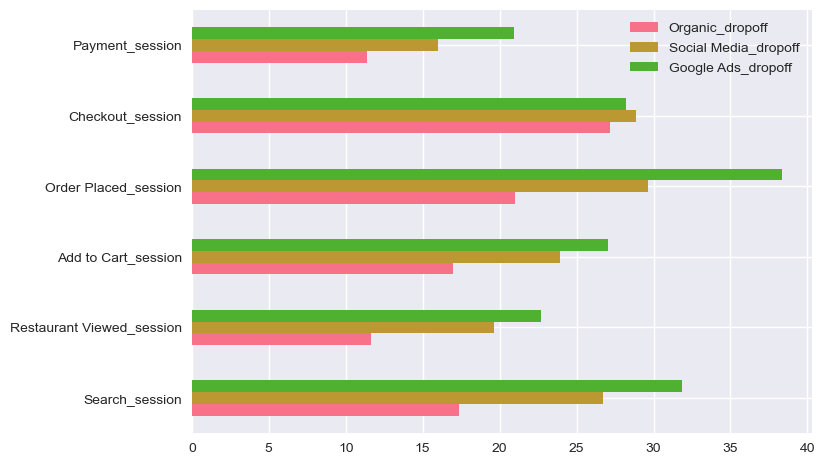

In [72]:
dropoff_channel.iloc[2:8:,4:7:].plot(kind='barh')

In [73]:

data_slice = dropoff_channel.iloc[7, 8::]

fig = px.bar(
    data_slice, 
    orientation='h',
    title="<b>Conversion Of Each Channel Breakdown</b>", # Bold, clean title
    color=data_slice.values,                  # Creates a color gradient based on values
    color_continuous_scale='Plasma',          # A sleek, vibrant color scheme
    text_auto='.2s'                           # Automatically adds formatted numbers to the bars
)

fig.update_layout(
    template='plotly_dark',                   # Instantly makes it look modern (Dark Mode)
    xaxis_title="Number of Users",            # Customize your axis labels
    yaxis_title="Channel",
    showlegend=False,                         # Hides the color bar legend to save space
    title_font_size=22,
    margin=dict(l=20, r=20, t=60, b=20)       # Adjusts spacing around the chart
)

# Clean up the background by removing gridlines
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

### Channel Insights

<div class="alert alert-info">
<b>Observation:</b> The conversion rate for Google Ads is the lowest among all acquisition channels.
</div>

**Hypothesis Tree:** The high drop-off rate from Google Ads is driven by the underlying stages of the user journey. By breaking down the funnel, we can isolate the potential root causes:

* `Restaurant View` &rarr; Users do not find their preferred items or are overwhelmed by immense options *(potential mismatch with the specific ad they clicked)*.
* `Add to Cart` &rarr; Users cannot find all the specific items they are looking for, prompting them to abandon their cart or look for better alternatives.
* `Check Out` &rarr; Users reach this step with clear intent, but drop off due to UI friction, internet connectivity issues, or unexpected delivery fees.
* `Order Placed` &rarr; Users from Tier 2/3 cities are highly price-sensitive and may abandon the transaction after seeing the final, overall cost (taxes, tips, delivery fees) right before confirming the order.

In [98]:
dropoff_channel

,Organic,Social Media,Google Ads,Email,Organic_dropoff,Social Media_dropoff,Google Ads_dropoff,Email_dropoff,Organic_top_conversion_rate_,Social Media_top_conversion_rate_,Google Ads_top_conversion_rate_,Email_top_conversion_rate_
total_sessions,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
App Open_session,1483.000000,1363.000000,1599.000000,1125.000000,0.00,0.00,0.00,0.00,100.00,100.00,100.00,100.00
Search_session,1226.000000,999.000000,1090.000000,902.000000,17.33,26.71,31.83,19.82,82.67,73.29,68.17,80.18
Restaurant Viewed_session,1083.000000,803.000000,843.000000,769.000000,11.66,19.62,22.66,14.75,73.03,58.91,52.72,68.36
Add to Cart_session,899.000000,611.000000,615.000000,622.000000,16.99,23.91,27.05,19.12,60.62,44.83,38.46,55.29
Order Placed_session,710.000000,430.000000,379.000000,466.000000,21.02,29.62,38.37,25.08,47.88,31.55,23.70,41.42
Checkout_session,517.000000,306.000000,272.000000,320.000000,27.18,28.84,28.23,31.33,34.86,22.45,17.01,28.44
Payment_session,458.000000,257.000000,215.000000,273.000000,11.41,16.01,20.96,14.69,30.88,18.86,13.45,24.27
session_per_channel,26.624776,24.470377,28.707361,20.197487,94.19,90.48,86.65,92.60,1.80,1.80,1.80,1.80


### Stage wise conversion Rate per Channel

In [101]:
conversion_channel =channel_df[channel_df.columns[channel_df.columns.str.contains('rate')]].copy()
conversion_channel.rename(index=channel_df['Channel'],inplace=True)

In [76]:
conversion_channel

,App Open_rate,Search_rate,Restaurant Viewed_rate,Add to Cart_rate,Order Placed_rate,Checkout_rate,Payment_rate,conversion_rate
Organic,100.0,82.670263,73.027647,60.620364,47.875927,34.861767,30.883345,30.883345
Social Media,100.0,73.294204,58.914160,44.827586,31.548056,22.450477,18.855466,18.855466
Google Ads,100.0,68.167605,52.720450,38.461538,23.702314,17.010632,13.445904,13.445904
Email,100.0,80.177778,68.355556,55.288889,41.422222,28.444444,24.266667,24.266667


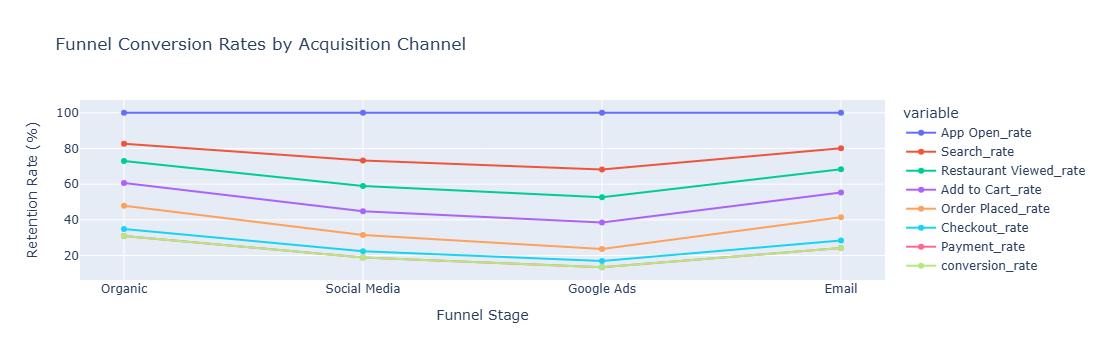

In [77]:
px.line(conversion_channel,markers=True,title='Funnel Conversion Rates by Acquisition Channel',labels={
        'index': 'Funnel Stage', 
        'value': 'Retention Rate (%)', 
        'Channel': 'Acquisition Channel'
    }
)

### Total Revenue Per Channel

In [78]:
px.bar(channel_df,x="Channel",y="total_revenue",title="Total Revenue by Acquisition Channel",color="Channel")

### Funneling Based by acquisition Location 

In [79]:
def location_funnel(summary_df):
    global funnel_stage
    location_funnel = {}
    locations = summary_df['city'].unique()
    count = None
    for location in locations:
        funnel_metrics = []

        
        for i,stage in enumerate(funnel_stage):
            if i ==0:
                count = len(summary_df[summary_df['city']==location])
                            
            else:
                count = len((summary_df[(summary_df['city']==location) & (summary_df['max_funnel_stage'].isin(funnel_stage[i:]))]))

            funnel_metrics.append(
                {
                    'stage':stage,
                    'sesssion':count
                }
            )
        location_funnel[location] = pd.DataFrame(funnel_metrics).set_index('stage')
    final_df = pd.concat(location_funnel, axis=1)
    # location_funnel = pd.DataFrame(location_funnel)
    return final_df

In [80]:
location_conversion = location_funnel(summ_df)
location_dropoff = location_funnel(summ_df)

### finding the Covnersion_rate and Dropoff rate for each city 

In [81]:
for city,_ in location_conversion.columns:
    location_conversion[f'{city}_conversion_rate'] = location_conversion[city].apply(lambda x:x/np.sum(location_conversion.iloc[0][city]))*100
    location_dropoff[f'{city}_dropoff_rate'] = 1 - location_dropoff[city]/location_dropoff[city].shift(1) 

In [82]:
location_dropoff.iloc[0,8::] = 0

In [83]:
location_conversion

,Delhi,Kolkata,Bangalore,Mumbai,Chennai,Ahmedabad,Hyderabad,Pune,Delhi_conversion_rate,Kolkata_conversion_rate,Bangalore_conversion_rate,Mumbai_conversion_rate,Chennai_conversion_rate,Ahmedabad_conversion_rate,Hyderabad_conversion_rate,Pune_conversion_rate
,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,,,,,,,,
stage,,,,,,,,,,,,,,,,
App Open,1006,440,963,1132,538,248,655,588,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
Search,749,330,738,866,409,197,481,447,74.453280,75.000000,76.635514,76.501767,76.022305,79.435484,73.435115,76.020408
Restaurant Viewed,622,276,609,711,334,172,401,373,61.829026,62.727273,63.239875,62.809187,62.081784,69.354839,61.221374,63.435374
Add to Cart,487,203,481,555,271,137,312,301,48.409543,46.136364,49.948079,49.028269,50.371747,55.241935,47.633588,51.190476
Order Placed,347,143,362,391,188,110,220,224,34.493042,32.500000,37.590862,34.540636,34.944238,44.354839,33.587786,38.095238
Checkout,244,106,256,289,131,75,168,146,24.254473,24.090909,26.583593,25.530035,24.349442,30.241935,25.648855,24.829932
Payment,201,90,227,249,109,66,142,119,19.980119,20.454545,23.572170,21.996466,20.260223,26.612903,21.679389,20.238095


In [84]:
location_dropoff

,Delhi,Kolkata,Bangalore,Mumbai,Chennai,Ahmedabad,Hyderabad,Pune,Delhi_dropoff_rate,Kolkata_dropoff_rate,Bangalore_dropoff_rate,Mumbai_dropoff_rate,Chennai_dropoff_rate,Ahmedabad_dropoff_rate,Hyderabad_dropoff_rate,Pune_dropoff_rate
,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,sesssion,,,,,,,,
stage,,,,,,,,,,,,,,,,
App Open,1006,440,963,1132,538,248,655,588,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Search,749,330,738,866,409,197,481,447,0.255467,0.250000,0.233645,0.234982,0.239777,0.205645,0.265649,0.239796
Restaurant Viewed,622,276,609,711,334,172,401,373,0.169559,0.163636,0.174797,0.178984,0.183374,0.126904,0.166320,0.165548
Add to Cart,487,203,481,555,271,137,312,301,0.217042,0.264493,0.210181,0.219409,0.188623,0.203488,0.221945,0.193029
Order Placed,347,143,362,391,188,110,220,224,0.287474,0.295567,0.247401,0.295495,0.306273,0.197080,0.294872,0.255814
Checkout,244,106,256,289,131,75,168,146,0.296830,0.258741,0.292818,0.260870,0.303191,0.318182,0.236364,0.348214
Payment,201,90,227,249,109,66,142,119,0.176230,0.150943,0.113281,0.138408,0.167939,0.120000,0.154762,0.184932


In [85]:
location_dropoff.index

Index(['App Open', 'Search', 'Restaurant Viewed', 'Add to Cart',
       'Order Placed', 'Checkout', 'Payment'],
      dtype='object', name='stage')

In [86]:
px.bar(
    location_dropoff*100, 
    y=location_dropoff.index, 
    x=['Delhi_dropoff_rate','Kolkata_dropoff_rate','Bangalore_dropoff_rate', 'Mumbai_dropoff_rate','Chennai_dropoff_rate','Ahmedabad_dropoff_rate',
       'Hyderabad_dropoff_rate', 'Pune_dropoff_rate'
      ], 
    # color='City', 
    barmode='group', # Groups them side-by-side instead of stacking
    orientation='h', # Makes the bars horizontal
    title='Dropoff Rate by City and Funnel Stage',
    labels={'Dropoff_Rate': 'Dropoff Rate (%)', 'Stage': 'Funnel Stage'},
    width= 1200,
    height = 500
)

### Location Insights

<div class="alert alert-info">
<b>Observation:</b> Dropoff Rate at Checkout and Payment stage is the highest for Pune city.
</div>
    


**Hypothesis Tree:** 

* `Dropoff at Checkout = (Total users who reach Checkout stage) x (%of People who drop)`


    * `Total users who reach Checkout stage:`

        * Regular Users .

        * Users who drop off when no promo code is available and the final price exceeds their threshold.

        * Low intent Users/ Impulse buyer that reach this stage due to curosity from the Ads.
    
    * `%of People who drop:`  

        *   Users might be looking for better alternative maybe because of high price or a sudden delivery charge which they were not expecting.

        *  Delivery time shown does not meet the user expectation.

        


### Retention Rate By Location

In [87]:
location_retention =  location_conversion.iloc[::,8::]


In [88]:
location_retention = location_retention.reset_index()

In [89]:
location_retention.columns = location_retention.columns.droplevel(1)


In [90]:
location_retention

,stage,Delhi_conversion_rate,Kolkata_conversion_rate,Bangalore_conversion_rate,Mumbai_conversion_rate,Chennai_conversion_rate,Ahmedabad_conversion_rate,Hyderabad_conversion_rate,Pune_conversion_rate
0,App Open,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,Search,74.453280,75.000000,76.635514,76.501767,76.022305,79.435484,73.435115,76.020408
2,Restaurant Viewed,61.829026,62.727273,63.239875,62.809187,62.081784,69.354839,61.221374,63.435374
3,Add to Cart,48.409543,46.136364,49.948079,49.028269,50.371747,55.241935,47.633588,51.190476
4,Order Placed,34.493042,32.500000,37.590862,34.540636,34.944238,44.354839,33.587786,38.095238
5,Checkout,24.254473,24.090909,26.583593,25.530035,24.349442,30.241935,25.648855,24.829932
6,Payment,19.980119,20.454545,23.572170,21.996466,20.260223,26.612903,21.679389,20.238095


In [91]:
location_retention = location_retention.set_index('stage')

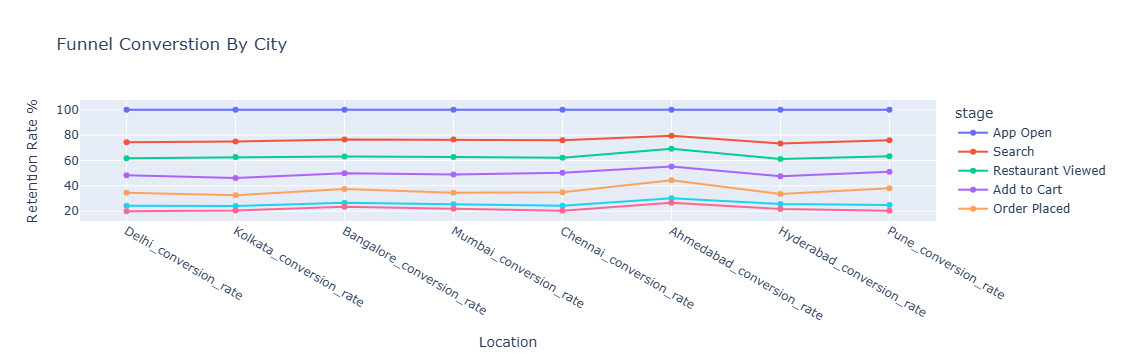

In [92]:
px.line(location_retention.T,title='Funnel Converstion By City',markers=True,labels={'index':'Location','value':'Retention Rate %'})